# 253. Can a search put a human ELM motif on its chicken ortholog?

A call **covers** a motif when the human side of the call holds at least 80% of the
motif's residues. Covering a motif with a call to *some* chicken protein is easy. Each
human query keeps its best 1_000 chicken proteins, and most motifs sit inside a longer
domain that many chicken proteins share. So the question asked here is narrower. Take a
human protein with a 1:1 ortholog in chicken: the same OMA group, one member in each
species. Did the search put the motif on the ortholog, **at the place where the motif sits
in the ortholog**?

"At the place" is measured against a protein alignment made without any of these
searches. Notebook 250 (Stage 0) aligned each human protein to its ortholog with MAFFT.
The motif's residues, carried through that alignment, give a stretch of ortholog
residues: the **projected motif**. A call to the ortholog is **on position** when its
chicken side holds at least 80% of the projected motif.

Inputs: 2_160 experimentally supported human ELM instances on 1_303 proteins. Of these,
550 are on a protein with a chicken ortholog. 540 of those have a projected motif; the
other 10 have no ortholog residue aligned to any motif residue. Every arm searched the
1_303 human proteins against the whole chicken proteome (QfO 2020_04, 17_837 proteins).
Only chicken has been searched so far.

The scores come from `scripts/reduce_elm_cover.py`, one run per arm, on Sherlock
(`make reduce-elm-cover`). Its tests are in
`nextflow-runs/qfo-pfam-region-benchmark/tests/test_reduce_elm_cover.py`.

In [1]:
import json
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

pl.Config.set_tbl_rows(60)
pl.Config.set_tbl_cols(20)
pl.Config.set_fmt_str_lengths(60)

COVER = Path(
    os.environ.get("ELM_COVER_DIR", "/Users/olga/data/elm-motif-transfer/cover/chicken")
)
CONF = Path("../nextflow-runs/qfo-pfam-region-benchmark/conf/elm_cover.config")
FIG = Path("../figures")
TAB = Path("../tables")

COMPARATORS = {
    "hmmer3_phmmer": "phmmer",
    "hmmer3_jackhmmer": "jackhmmer",
    "mmseqs2_seqseq": "MMseqs2",
    "mmseqs2_iterative": "MMseqs2, iterative",
    "hhblits": "HHblits",
    "foldseek": "Foldseek",
    "prostt5": "Foldseek with ProstT5",
    "reseek": "Reseek",
}
ARM_RE = re.compile(
    r"^(?P<alphabet>.+)\.k(?P<k>\d+)(?:\.s(?P<scaled>\d+))?\.lc(?P<mask>true|false)$"
)


def parse_arm(arm):
    if arm in COMPARATORS:
        return {
            "tool": COMPARATORS[arm],
            "alphabet": None,
            "k": None,
            "scaled": None,
            "mask": None,
        }
    m = ARM_RE.match(arm)
    return {
        "tool": "kmerseek",
        "alphabet": m["alphabet"],
        "k": int(m["k"]),
        "scaled": int(m["scaled"] or 1),
        "mask": m["mask"] == "true",
    }


def arm_label(arm):
    p = parse_arm(arm)
    if p["tool"] != "kmerseek":
        return p["tool"]
    return (
        f"kmerseek {p['alphabet']}, k = {p['k']}, scaled {p['scaled']}, "
        f"mask {'on' if p['mask'] else 'off'}"
    )


summaries = [json.loads(p.read_text()) for p in sorted(COVER.glob("*.summary.json"))]
S = pl.DataFrame(
    [
        {
            **{k: v for k, v in s.items() if k != "length_check"},
            "spearman_vs_length": (s.get("length_check") or {}).get(
                "spearman_vs_length"
            ),
            **parse_arm(s["arm"]),
        }
        for s in summaries
    ],
    infer_schema_length=None,
)
I = pl.concat(
    [pl.read_parquet(p) for p in sorted(COVER.glob("*.instances.parquet"))],
    how="diagonal_relaxed",
)
# Foldseek and Reseek count along the AlphaFold model; a query whose model is not the QfO
# sequence is not scoreable for them (reduce_elm_cover.py). Arms scored before that column
# existed are sequence arms, where every query is scoreable.
if "query_scoreable" not in I.columns:
    I = I.with_columns(query_scoreable=pl.lit(True))
I = I.with_columns(pl.col("query_scoreable").fill_null(True))
I = I.join(S.select("arm", "tool", "alphabet", "k", "scaled", "mask"), on="arm")
print(
    f"{S.height} arms with a summary: {S['status'].value_counts().sort('status').rows()}"
)
print("Motifs left out because the query's AlphaFold model is not its QfO sequence:")
print(
    I.group_by("tool")
    .agg(not_scoreable=(~pl.col("query_scoreable")).sum() / pl.col("arm").n_unique())
    .filter(pl.col("not_scoreable") > 0)
)
print(
    f"{I['elm_instance'].n_unique()} ELM instances; {I.filter('has_ortholog')['elm_instance'].n_unique()} on a protein "
    f"with a chicken ortholog; {I.filter('has_projection')['elm_instance'].n_unique()} with a projected motif"
)

276 arms with a summary: [('empty', 2), ('ok', 274)]
Motifs left out because the query's AlphaFold model is not its QfO sequence:
shape: (2, 2)
┌──────────┬───────────────┐
│ tool     ┆ not_scoreable │
│ ---      ┆ ---           │
│ str      ┆ f64           │
╞══════════╪═══════════════╡
│ Reseek   ┆ 106.0         │
│ Foldseek ┆ 106.0         │
└──────────┴───────────────┘
2160 ELM instances; 550 on a protein with a chicken ortholog; 540 with a projected motif


## 1. Which arms ran

An arm is one search setting. For kmerseek that is an alphabet, a k-mer length k, the
low-complexity mask off or on, and scaled 1, 2, 5 or 10. Scaled s keeps about one k-mer in
s from the chicken proteome, so the index is smaller. The eight comparison tools are one
arm each. The kmerseek arms that should exist are read from the search's own
configuration. So an arm that never wrote a result shows up here as missing, not as an arm
that found nothing.

In [2]:
conf = CONF.read_text()
combos = re.search(r"kmerseek_combos\s*=\s*'([^']+)'", conf)[1].split(",")
scaled_set = [
    int(x) for x in re.search(r"kmerseek_scaled\s*=\s*'([^']+)'", conf)[1].split(",")
]
masks = re.search(r"low_complexity_toggle\s*=\s*'([^']+)'", conf)[1].split(",")
expected = pl.DataFrame(
    [
        {"alphabet": a, "k": int(k), "scaled": s, "mask": m == "true"}
        for a, k in (c.split(":") for c in combos)
        for s in scaled_set
        for m in masks
    ]
)
km = S.filter(pl.col("tool") == "kmerseek").select(
    "alphabet", "k", "scaled", "mask", "status"
)
arms = expected.join(
    km, on=["alphabet", "k", "scaled", "mask"], how="left"
).with_columns(pl.col("status").fill_null("no result file"))
status = arms.group_by("status").len().sort("status")
print(f"kmerseek arms in the configuration: {expected.height}")
print(status)
print("\nArms without a usable result:")
print(arms.filter(pl.col("status") != "ok").sort("alphabet", "k", "scaled", "mask"))
comp = S.filter(pl.col("tool") != "kmerseek").select("tool", "status").sort("tool")
print("\nComparison tools:")
print(comp)
arms.write_csv(TAB / "253_arm_status.csv")

kmerseek arms in the configuration: 272
shape: (3, 2)
┌────────────────┬─────┐
│ status         ┆ len │
│ ---            ┆ --- │
│ str            ┆ u32 │
╞════════════════╪═════╡
│ empty          ┆ 2   │
│ no result file ┆ 4   │
│ ok             ┆ 266 │
└────────────────┴─────┘

Arms without a usable result:
shape: (6, 5)
┌─────────────┬─────┬────────┬───────┬────────────────┐
│ alphabet    ┆ k   ┆ scaled ┆ mask  ┆ status         │
│ ---         ┆ --- ┆ ---    ┆ ---   ┆ ---            │
│ str         ┆ i64 ┆ i64    ┆ bool  ┆ str            │
╞═════════════╪═════╪════════╪═══════╪════════════════╡
│ funcgroups8 ┆ 7   ┆ 1      ┆ false ┆ empty          │
│ funcgroups8 ┆ 7   ┆ 1      ┆ true  ┆ empty          │
│ gbmr7       ┆ 10  ┆ 1      ┆ false ┆ no result file │
│ gbmr7       ┆ 10  ┆ 2      ┆ false ┆ no result file │
│ gbmr7       ┆ 10  ┆ 5      ┆ false ┆ no result file │
│ gbmr7       ┆ 10  ┆ 10     ┆ false ┆ no result file │
└─────────────┴─────┴────────┴───────┴────────────────┘

Com

## 2. Covering a motif is easy; putting it on position is not

Each check below is stricter than the one before it. The **placement check** is from
notebook 250. Drop a window the same length as the call at a random place on the human
protein: how often does it also cover the motif? A call passes when that happens less than
5% of the time. The check looks at the human side only. So a long alignment of a whole
ortholog fails it even when it is right, because a window that long covers the motif
wherever it is dropped. The on-position check does not have that problem: it asks where
the call sits on the chicken side.

Share of motifs passing each check (kmerseek: the one arm with the highest on-position share):
shape: (9, 5)
┌───────────────────┬───────────────────┬───────────────────┬───────────────────┬──────────────────┐
│ tool              ┆ covered, any      ┆ covered, on the   ┆ covered on the    ┆ on the ortholog, │
│ ---               ┆ chicken protein   ┆ ortholog (of 550) ┆ ortholog, passes  ┆ on position (of  │
│ str               ┆ (of 2_160)        ┆ ---               ┆ the placement     ┆ 540)             │
│                   ┆ ---               ┆ f64               ┆ check (of 550)    ┆ ---              │
│                   ┆ f64               ┆                   ┆ ---               ┆ f64              │
│                   ┆                   ┆                   ┆ f64               ┆                  │
╞═══════════════════╪═══════════════════╪═══════════════════╪═══════════════════╪══════════════════╡
│ jackhmmer         ┆ 0.988426          ┆ 0.974545          ┆ 0.014545          ┆ 0

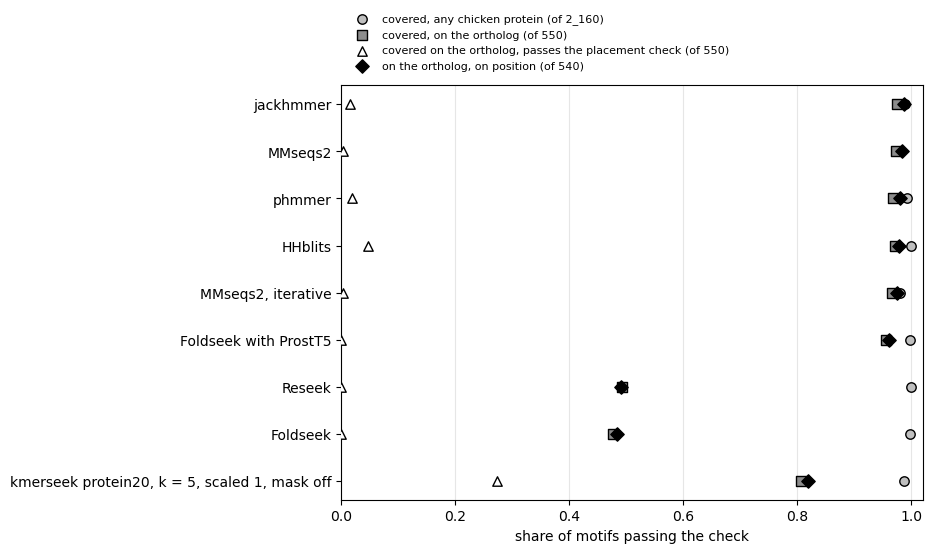

In [3]:
def shares(frame):
    frame = frame.filter("query_scoreable")
    orth = frame.filter("has_ortholog")
    proj = frame.filter("has_projection")
    return {
        "covered, any chicken protein (of 2_160)": frame["best_rank"]
        .is_not_null()
        .mean(),
        "covered, on the ortholog (of 550)": orth["ortholog_rank"].is_not_null().mean(),
        "covered on the ortholog, passes the placement check (of 550)": orth[
            "ortholog_rank_placed"
        ]
        .is_not_null()
        .mean(),
        "on the ortholog, on position (of 540)": proj["ortholog_rank_on_position"]
        .is_not_null()
        .mean(),
    }


ok = S.filter(pl.col("status") == "ok")["arm"].to_list()
rows = []
for arm in ok:
    rows.append({"arm": arm, **shares(I.filter(pl.col("arm") == arm))})
SH = pl.DataFrame(rows).join(
    S.select("arm", "tool", "alphabet", "k", "scaled", "mask"), on="arm"
)
CHECKS = [c for c in SH.columns if c.startswith(("covered", "on the"))]
best_km = (
    SH.filter(pl.col("tool") == "kmerseek")
    .sort(CHECKS[-1], "arm", descending=[True, False])
    .head(1)
)
show = pl.concat(
    [
        SH.filter(pl.col("tool") != "kmerseek").sort(CHECKS[-1], descending=True),
        best_km.with_columns(
            tool=pl.col("arm").map_elements(arm_label, return_dtype=pl.String)
        ),
    ]
)
print(
    "Share of motifs passing each check (kmerseek: the one arm with the highest on-position share):"
)
print(show.select("tool", *CHECKS))
show.select("tool", *CHECKS).write_csv(TAB / "253_checks_by_tool.csv")

markers = ["o", "s", "^", "D"]
fills = ["0.75", "0.55", "white", "black"]
fig, ax = plt.subplots(figsize=(7.5, 0.42 * show.height + 1.6))
labels = show["tool"].to_list()
for j, c in enumerate(CHECKS):
    ax.scatter(
        show[c],
        range(show.height),
        marker=markers[j],
        s=46,
        facecolor=fills[j],
        edgecolor="black",
        zorder=3,
        label=c,
    )
ax.set_yticks(range(show.height), labels)
ax.invert_yaxis()
ax.set_xlim(0, 1.02)
ax.set_xlabel("share of motifs passing the check")
ax.grid(axis="x", color="0.9", zorder=0)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01), ncol=1, frameon=False, fontsize=8)
fig.savefig(FIG / "253_checks_by_tool.png", dpi=200, bbox_inches="tight")

Every tool covers almost every motif with a call to *some* chicken protein (97% to 100%), so that check says nothing. The placement check rejects almost every correct call. For the six sequence tools, 0% to 5% of motifs pass it, while 96% to 99% are on position.

On position, the six sequence tools reach 96.1% (Foldseek with ProstT5) to 98.7% (jackhmmer). Foldseek (48.4%) and Reseek (49.2%) reach about half. Their share leaves out 106 motifs whose query's AlphaFold model does not match the QfO sequence. The best kmerseek arm, protein20 with k = 5 at scaled 1, puts 442 of 540 motifs on position (81.9%).

## 3. Every kmerseek arm, on position

One point per kmerseek arm at scaled 1 (the full chicken index). Shape is the k-mer
length: each alphabet was run at two k (the shorter one only where the search fit in
memory, notebook 250 step 5). Filled means the low-complexity mask was off, open means on.
The comparison tools, from section 2, are the grey rows at the top.

kmerseek at scaled 1, share on position (of 540):
shape: (65, 4)
┌──────────────────────────┬─────┬───────┬───────────────────────────────────────┐
│ alphabet                 ┆ k   ┆ mask  ┆ on the ortholog, on position (of 540) │
│ ---                      ┆ --- ┆ ---   ┆ ---                                   │
│ str                      ┆ i64 ┆ bool  ┆ f64                                   │
╞══════════════════════════╪═════╪═══════╪═══════════════════════════════════════╡
│ dayhoff6                 ┆ 7   ┆ false ┆ 0.201852                              │
│ dayhoff6                 ┆ 7   ┆ true  ┆ 0.2                                   │
│ dayhoff6                 ┆ 9   ┆ false ┆ 0.627778                              │
│ dayhoff6                 ┆ 9   ┆ true  ┆ 0.627778                              │
│ funcgroups8              ┆ 6   ┆ false ┆ 0.492593                              │
│ funcgroups8              ┆ 6   ┆ true  ┆ 0.494444                              │
│ gbmr4               

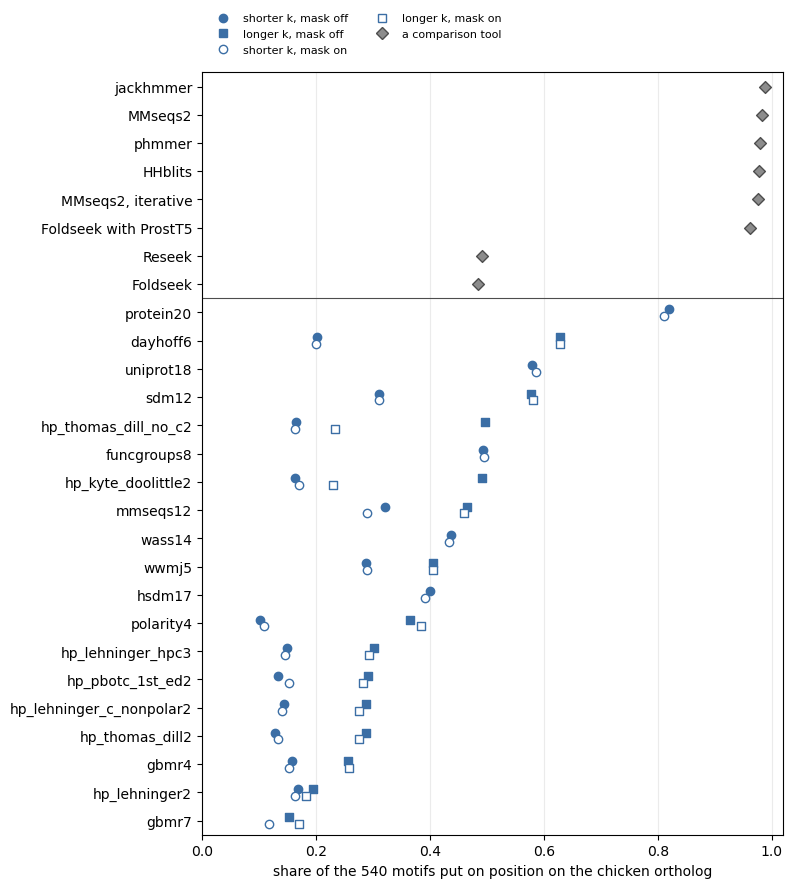

In [4]:
k1 = SH.filter((pl.col("tool") == "kmerseek") & (pl.col("scaled") == 1)).with_columns(
    k_rank=pl.col("k").rank("dense").over("alphabet")
)
order = (
    k1.group_by("alphabet")
    .agg(best=pl.col(CHECKS[-1]).max())
    .sort("best", "alphabet", descending=[True, False])["alphabet"]
    .to_list()
)
print("kmerseek at scaled 1, share on position (of 540):")
print(k1.select("alphabet", "k", "mask", CHECKS[-1]).sort("alphabet", "k", "mask"))
k1.select("alphabet", "k", "mask", *CHECKS).write_csv(TAB / "253_kmerseek_scaled1.csv")

comp_rows = SH.filter(pl.col("tool") != "kmerseek").sort(CHECKS[-1], descending=True)
names = comp_rows["tool"].to_list() + order
fig, ax = plt.subplots(figsize=(7.5, 0.3 * len(names) + 1.8))
for i, r in enumerate(comp_rows.iter_rows(named=True)):
    ax.scatter(
        r[CHECKS[-1]], i, marker="D", s=36, facecolor="0.55", edgecolor="0.3", zorder=3
    )
ax.axhline(comp_rows.height - 0.5, color="0.3", lw=0.8)
y = {a: comp_rows.height + i for i, a in enumerate(order)}
for r in k1.iter_rows(named=True):
    ax.scatter(
        r[CHECKS[-1]],
        y[r["alphabet"]] + (0.12 if r["mask"] else -0.12),
        marker="o" if r["k_rank"] == 1 else "s",
        s=36,
        facecolor="white" if r["mask"] else "#3B6EA5",
        edgecolor="#3B6EA5",
        zorder=3,
    )
ax.set_yticks(range(len(names)), names)
ax.set_ylim(len(names) - 0.5, -0.5)
ax.set_xlim(0, 1.02)
ax.set_xlabel("share of the 540 motifs put on position on the chicken ortholog")
handles = [
    plt.Line2D(
        [],
        [],
        marker="o",
        ls="",
        mfc="#3B6EA5",
        mec="#3B6EA5",
        label="shorter k, mask off",
    ),
    plt.Line2D(
        [],
        [],
        marker="s",
        ls="",
        mfc="#3B6EA5",
        mec="#3B6EA5",
        label="longer k, mask off",
    ),
    plt.Line2D(
        [],
        [],
        marker="o",
        ls="",
        mfc="white",
        mec="#3B6EA5",
        label="shorter k, mask on",
    ),
    plt.Line2D(
        [], [], marker="s", ls="", mfc="white", mec="#3B6EA5", label="longer k, mask on"
    ),
    plt.Line2D(
        [], [], marker="D", ls="", mfc="0.55", mec="0.3", label="a comparison tool"
    ),
]
ax.legend(
    handles=handles,
    loc="lower left",
    bbox_to_anchor=(0, 1.01),
    ncol=2,
    frameon=False,
    fontsize=8,
)
ax.grid(axis="x", color="0.92", zorder=0)
fig.savefig(FIG / "253_kmerseek_scaled1.png", dpi=200, bbox_inches="tight")

At scaled 1, the longer k puts more motifs on position in 27 of the 28 alphabet-and-mask pairs run at both k. For example, dayhoff6 reaches 20% at k = 7 and 63% at k = 9. The low-complexity mask changes the share by a median of 0.6 points. The two exceptions are hp_thomas_dill_no_c2 and hp_kyte_doolittle2 at k = 20, where the mask halves it (50% to 23%, and 49% to 23%). The hydrophobic-polar (HP) alphabets put 13% to 50% of the motifs on position at scaled 1.

## 4. What a smaller index costs

For each kmerseek alphabet, k and mask, the on-position share at scaled 2, 5 and 10
divided by the share at scaled 1. A ratio of 1 means subsampling the chicken k-mers lost
nothing.

On-position share relative to scaled 1, over arms with a nonzero share at scaled 1:
shape: (3, 5)
┌────────┬────────┬──────────────┬──────────┬──────────┐
│ scaled ┆ n_arms ┆ median_ratio ┆ q25      ┆ q75      │
│ ---    ┆ ---    ┆ ---          ┆ ---      ┆ ---      │
│ i64    ┆ u32    ┆ f64          ┆ f64      ┆ f64      │
╞════════╪════════╪══════════════╪══════════╪══════════╡
│ 2      ┆ 65     ┆ 1.288591     ┆ 1.043956 ┆ 1.436508 │
│ 5      ┆ 65     ┆ 1.812785     ┆ 1.529412 ┆ 2.134969 │
│ 10     ┆ 65     ┆ 2.023121     ┆ 1.684932 ┆ 2.348684 │
└────────┴────────┴──────────────┴──────────┴──────────┘


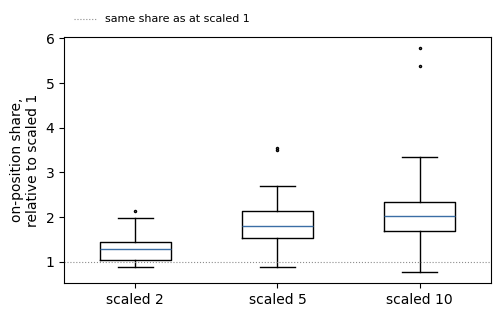

In [5]:
km_all = SH.filter(pl.col("tool") == "kmerseek")
base = km_all.filter(pl.col("scaled") == 1).select(
    "alphabet", "k", "mask", base=pl.col(CHECKS[-1])
)
ratio = (
    km_all.filter(pl.col("scaled") > 1)
    .join(base, on=["alphabet", "k", "mask"])
    .filter(pl.col("base") > 0)
    .with_columns(ratio=pl.col(CHECKS[-1]) / pl.col("base"))
)
summ = (
    ratio.group_by("scaled")
    .agg(
        n_arms=pl.len(),
        median_ratio=pl.col("ratio").median(),
        q25=pl.col("ratio").quantile(0.25),
        q75=pl.col("ratio").quantile(0.75),
    )
    .sort("scaled")
)
print(
    "On-position share relative to scaled 1, over arms with a nonzero share at scaled 1:"
)
print(summ)
summ.write_csv(TAB / "253_scaled_cost.csv")

if summ.is_empty():
    print(
        "No arm has both scaled 1 and a larger scaled with a result, so there is nothing to compare."
    )
else:
    fig, ax = plt.subplots(figsize=(5.5, 3.2))
    data = [
        ratio.filter(pl.col("scaled") == s)["ratio"].to_numpy() for s in summ["scaled"]
    ]
    ax.boxplot(
        data,
        tick_labels=[f"scaled {s}" for s in summ["scaled"]],
        widths=0.5,
        medianprops={"color": "#3B6EA5"},
        flierprops={"marker": ".", "markersize": 3},
    )
    ax.axhline(1, color="0.55", ls=":", lw=0.8, label="same share as at scaled 1")
    ax.set_ylabel("on-position share,\nrelative to scaled 1")
    ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01), frameon=False, fontsize=8)
    fig.savefig(FIG / "253_scaled_cost.png", dpi=200, bbox_inches="tight")

Subsampling the chicken index raises the share instead of lowering it. The comparison uses the 65 alphabet, k and mask settings with a nonzero share at scaled 1. Against scaled 1, the median share is 1.29 times higher at scaled 2, 1.81 times at scaled 5 and 2.02 times at scaled 10.

This notebook does not explain it. Section 5 shows that kmerseek puts the ortholog low in the query's list. Section 7 shows that its ranking score follows call length. One reading is that a smaller index leaves fewer long calls to other proteins above the ortholog, before the cut to 1_000 targets. That reading is not tested here.

## 5. Rank of the ortholog, when it is on position

Rank is the ortholog's place in the query's list of chicken proteins, ordered by each
protein's best call: rank 1 means the ortholog was the best chicken hit. Shown for the
comparison tools and for the best kmerseek arm of section 2.

Motifs on position (of 540), by the ortholog's rank in the query's list:
shape: (9, 5)
┌─────────────────────────────────────────────┬─────────────┬────────┬──────────────┬──────────────┐
│ label                                       ┆ on_position ┆ rank_1 ┆ rank_2_to_10 ┆ rank_over_10 │
│ ---                                         ┆ ---         ┆ ---    ┆ ---          ┆ ---          │
│ str                                         ┆ u32         ┆ u32    ┆ u32          ┆ u32          │
╞═════════════════════════════════════════════╪═════════════╪════════╪══════════════╪══════════════╡
│ jackhmmer                                   ┆ 533         ┆ 491    ┆ 42           ┆ 0            │
│ MMseqs2                                     ┆ 531         ┆ 497    ┆ 34           ┆ 0            │
│ phmmer                                      ┆ 529         ┆ 492    ┆ 37           ┆ 0            │
│ HHblits                                     ┆ 528         ┆ 485    ┆ 43           ┆ 0            │
│ MM

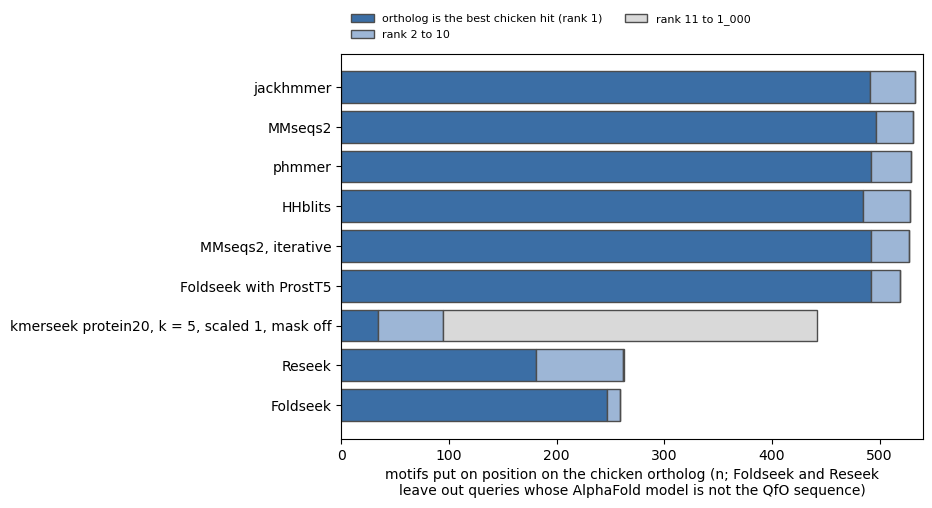

In [6]:
pick = (
    SH.filter(pl.col("tool") != "kmerseek")["arm"].to_list() + best_km["arm"].to_list()
)
R = I.filter(
    pl.col("arm").is_in(pick) & pl.col("has_projection") & pl.col("query_scoreable")
).with_columns(label=pl.col("arm").map_elements(arm_label, return_dtype=pl.String))
rk = (
    R.group_by("label")
    .agg(
        on_position=pl.col("ortholog_rank_on_position").is_not_null().sum(),
        rank_1=(pl.col("ortholog_rank_on_position") == 1).sum(),
        rank_2_to_10=pl.col("ortholog_rank_on_position").is_between(2, 10).sum(),
        rank_over_10=(pl.col("ortholog_rank_on_position") > 10).sum(),
    )
    .sort("on_position", descending=True)
)
print("Motifs on position (of 540), by the ortholog's rank in the query's list:")
print(rk)
rk.write_csv(TAB / "253_ortholog_rank.csv")

fig, ax = plt.subplots(figsize=(7.5, 0.4 * rk.height + 1.4))
left = np.zeros(rk.height)
for col, colour, name in [
    ("rank_1", "#3B6EA5", "ortholog is the best chicken hit (rank 1)"),
    ("rank_2_to_10", "#9DB6D6", "rank 2 to 10"),
    ("rank_over_10", "0.85", "rank 11 to 1_000"),
]:
    ax.barh(rk["label"], rk[col], left=left, color=colour, edgecolor="0.3", label=name)
    left += rk[col].to_numpy()
ax.invert_yaxis()
ax.set_xlim(0, R.group_by("label").len()["len"].max())
ax.set_xlabel(
    "motifs put on position on the chicken ortholog (n; Foldseek and Reseek\n"
    "leave out queries whose AlphaFold model is not the QfO sequence)"
)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01), ncol=2, frameon=False, fontsize=8)
fig.savefig(FIG / "253_ortholog_rank.png", dpi=200, bbox_inches="tight")

When a sequence tool puts the motif on position, the ortholog is its best chicken hit for 485 to 497 of 540 motifs, and never below rank 10. For the best kmerseek arm the ortholog is the best hit for 34 of its 442 motifs, and below rank 10 for 348 of them.

## 6. Motifs only kmerseek puts on position

A motif that no comparison tool puts on position, but at least one kmerseek arm does. The
first count pools every kmerseek arm, so it is an upper bound: with 266 arms, some will
land by chance. The second count uses only the best arm of section 2. That arm was chosen
on these same motifs, so its count is also optimistic.

motifs with a projected motif: 540
on position for at least one comparison tool: 537
on position for no comparison tool, but for at least one kmerseek arm: 0
  ... and for the best kmerseek arm (kmerseek protein20, k = 5, scaled 1, mask off): 0
shape: (0, 10)
┌──────────┬──────────┬──────────┬───────┬─────┬──────────┬──────────┬─────────┬─────────┬─────────┐
│ elm_inst ┆ elm_clas ┆ accessio ┆ start ┆ end ┆ motif_le ┆ length_b ┆ any_com ┆ n_km_ar ┆ best_ar │
│ ance     ┆ s        ┆ n        ┆ ---   ┆ --- ┆ ngth     ┆ in       ┆ parator ┆ ms      ┆ m       │
│ ---      ┆ ---      ┆ ---      ┆ i64   ┆ i64 ┆ ---      ┆ ---      ┆ ---     ┆ ---     ┆ ---     │
│ str      ┆ str      ┆ str      ┆       ┆     ┆ i64      ┆ str      ┆ bool    ┆ u32     ┆ bool    │
╞══════════╪══════════╪══════════╪═══════╪═════╪══════════╪══════════╪═════════╪═════════╪═════════╡
└──────────┴──────────┴──────────┴───────┴─────┴──────────┴──────────┴─────────┴─────────┴─────────┘


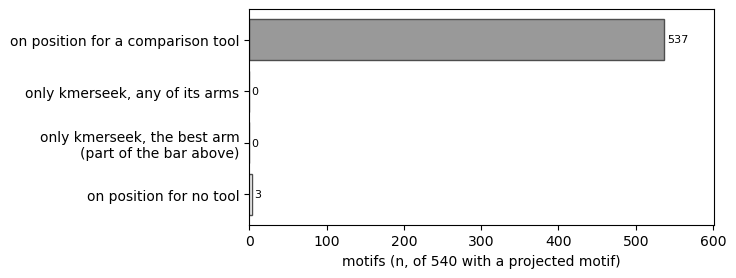

In [7]:
proj = I.filter("has_projection")
by_comp = (
    proj.filter(pl.col("tool") != "kmerseek")
    .group_by("elm_instance")
    .agg(any_comparator=pl.col("ortholog_rank_on_position").is_not_null().any())
)
by_km = (
    proj.filter(pl.col("tool") == "kmerseek")
    .group_by("elm_instance")
    .agg(n_km_arms=pl.col("ortholog_rank_on_position").is_not_null().sum())
)
by_best = proj.filter(pl.col("arm") == best_km["arm"][0]).select(
    "elm_instance", best_arm=pl.col("ortholog_rank_on_position").is_not_null()
)
U = (
    proj.select(
        "elm_instance",
        "elm_class",
        "accession",
        "start",
        "end",
        "motif_length",
        "length_bin",
    )
    .unique()
    .join(by_comp, on="elm_instance")
    .join(by_km, on="elm_instance")
    .join(by_best, on="elm_instance")
)
only_km = U.filter(~pl.col("any_comparator") & (pl.col("n_km_arms") > 0))
print(f"motifs with a projected motif: {U.height}")
print(f"on position for at least one comparison tool: {U['any_comparator'].sum()}")
print(
    f"on position for no comparison tool, but for at least one kmerseek arm: {only_km.height}"
)
print(
    f"  ... and for the best kmerseek arm ({arm_label(best_km['arm'][0])}): {only_km['best_arm'].sum()}"
)
print(only_km.sort("n_km_arms", descending=True).head(20))
only_km.write_csv(TAB / "253_only_kmerseek.csv")

fig, ax = plt.subplots(figsize=(6, 2.8))
vals = [
    U["any_comparator"].sum(),
    only_km.height,
    int(only_km["best_arm"].sum()),
    U.height - U["any_comparator"].sum() - only_km.height,
]
names = [
    "on position for a comparison tool",
    "only kmerseek, any of its arms",
    "only kmerseek, the best arm\n(part of the bar above)",
    "on position for no tool",
]
ax.barh(
    names,
    vals,
    color=["0.6", "#3B6EA5", "#3B6EA5", "white"],
    edgecolor="0.3",
    hatch=[None, None, "//", None],
)
for i, v in enumerate(vals):
    ax.text(v + 3, i, f"{v}", va="center", fontsize=8)
ax.invert_yaxis()
ax.set_xlim(0, 1.12 * max(vals))
ax.set_xlabel(f"motifs (n, of {U.height} with a projected motif)")
fig.savefig(FIG / "253_only_kmerseek.png", dpi=200, bbox_inches="tight")

537 of the 540 motifs are put on position by at least one comparison tool. No motif is put on position by a kmerseek arm and by none of the comparison tools, pooling all 266 arms.

## 7. Which tool's misses kmerseek places

For each comparison tool: the motifs it does not put on position, and how many of those the
best kmerseek arm of section 2 does. Foldseek and Reseek count only the motifs whose AlphaFold
model is the QfO sequence (535). The best arm was chosen on these same motifs, so its counts
are an upper bound.


kmerseek arm: kmerseek protein20, k = 5, scaled 1, mask off
shape: (8, 6)
┌───────────────────────┬───────────┬────────┬─────────────┬────────┬──────────────────────────────┐
│ tool                  ┆ structure ┆ motifs ┆ on position ┆ missed ┆ missed, kmerseek on position │
│ ---                   ┆ ---       ┆ ---    ┆ ---         ┆ ---    ┆ ---                          │
│ str                   ┆ bool      ┆ i64    ┆ i64         ┆ i64    ┆ i64                          │
╞═══════════════════════╪═══════════╪════════╪═════════════╪════════╪══════════════════════════════╡
│ jackhmmer             ┆ false     ┆ 540    ┆ 533         ┆ 7      ┆ 0                            │
│ MMseqs2               ┆ false     ┆ 540    ┆ 531         ┆ 9      ┆ 0                            │
│ phmmer                ┆ false     ┆ 540    ┆ 529         ┆ 11     ┆ 0                            │
│ HHblits               ┆ false     ┆ 540    ┆ 528         ┆ 12     ┆ 2                            │
│ MMseqs2, iterat

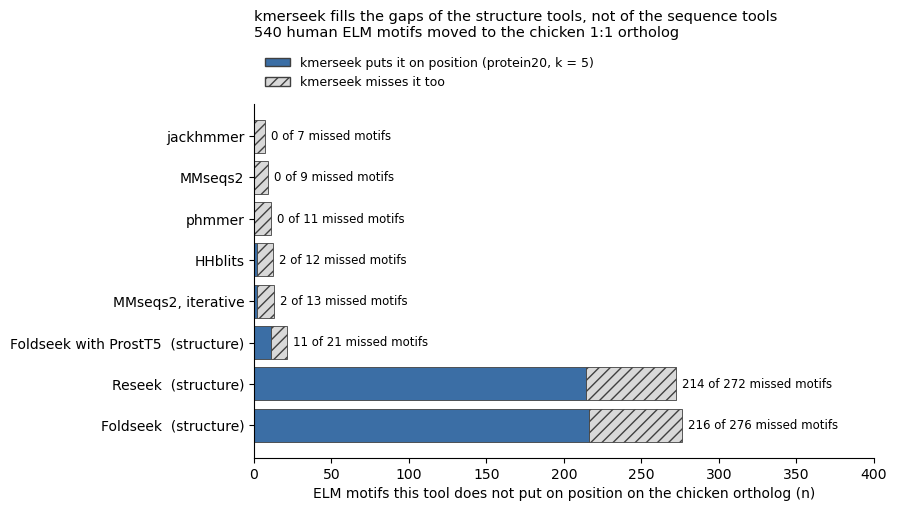

In [8]:
best_arm = best_km["arm"][0]
km_hit = proj.filter(pl.col("arm") == best_arm).select(
    "elm_instance", km=pl.col("ortholog_rank_on_position").is_not_null()
)
STRUCTURE = {"Foldseek", "Foldseek with ProstT5", "Reseek"}
rows = []
for arm, tool in COMPARATORS.items():
    t = (
        proj.filter((pl.col("arm") == arm) & pl.col("query_scoreable"))
        .with_columns(hit=pl.col("ortholog_rank_on_position").is_not_null())
        .join(km_hit, on="elm_instance")
    )
    miss = t.filter(~pl.col("hit"))
    rows.append(
        {
            "tool": tool,
            "structure": tool in STRUCTURE,
            "motifs": t.height,
            "on position": int(t["hit"].sum()),
            "missed": miss.height,
            "missed, kmerseek on position": int(miss["km"].sum()),
        }
    )
MISS = pl.DataFrame(rows).sort("missed")
print(f"kmerseek arm: {arm_label(best_arm)}")
print(MISS)
MISS.write_csv(TAB / "253_misses_by_tool.csv")

blue, grey = "#3B6EA5", "#D9D9D9"
fig, ax = plt.subplots(figsize=(8, 4.6))
y = range(MISS.height)
filled = MISS["missed, kmerseek on position"]
ax.barh(y, filled, color=blue, edgecolor="0.25", lw=0.6)
ax.barh(
    y,
    MISS["missed"] - filled,
    left=filled,
    color=grey,
    edgecolor="0.25",
    lw=0.6,
    hatch="///",
)
for i, r in enumerate(MISS.iter_rows(named=True)):
    ax.text(
        r["missed"] + 4,
        i,
        f"{r['missed, kmerseek on position']} of {r['missed']} missed motifs",
        va="center",
        fontsize=8.5,
    )
ax.set_yticks(
    list(y),
    [f"{t}  (structure)" if s else t for t, s in zip(MISS["tool"], MISS["structure"])],
)
ax.invert_yaxis()
ax.set_xlim(0, 400)
ax.set_xlabel("ELM motifs this tool does not put on position on the chicken ortholog (n)")
ax.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, facecolor=blue, edgecolor="0.25",
                      label="kmerseek puts it on position (protein20, k = 5)"),
        plt.Rectangle((0, 0), 1, 1, facecolor=grey, edgecolor="0.25", hatch="///",
                      label="kmerseek misses it too"),
    ],
    loc="lower left",
    bbox_to_anchor=(0, 1.01),
    frameon=False,
    fontsize=9,
)
ax.set_title(
    "kmerseek fills the gaps of the structure tools, not of the sequence tools\n"
    "540 human ELM motifs moved to the chicken 1:1 ortholog",
    loc="left",
    fontsize=10.5,
    pad=48,
)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
fig.savefig(FIG / "253_misses_by_tool.png", dpi=200, bbox_inches="tight")


Foldseek and Reseek miss about half the motifs (276 and 272), and kmerseek puts 216 and 214 of
those on position. The sequence tools miss 7 to 13 each, and kmerseek places 0 to 2 of them.
Foldseek misses 54% of the disordered motifs and 44% of the ordered ones (section 8), so its
losses are not only in disordered stretches. On chicken, every motif kmerseek adds to a
structure tool is one a sequence tool also finds.


## 8. By motif length and disorder

Share of motifs put on position, split by motif length and by whether most of the motif is
disordered (`frac_disordered_motif` >= 0.5, from `elm_instance_covariates.parquet`). Four tools:
the two best sequence tools, Foldseek, and the best kmerseek arm.


Share on position by length:
shape: (3, 5)
┌─────────┬──────────┬───────────────────────────┬───────────┬──────────┐
│ length  ┆ Foldseek ┆ kmerseek, protein20 k = 5 ┆ jackhmmer ┆ MMseqs2  │
│ ---     ┆ ---      ┆ ---                       ┆ ---       ┆ ---      │
│ str     ┆ f64      ┆ f64                       ┆ f64       ┆ f64      │
╞═════════╪══════════╪═══════════════════════════╪═══════════╪══════════╡
│ 11+ aa  ┆ 0.462963 ┆ 0.927273                  ┆ 1.0       ┆ 1.0      │
│ 3-6 aa  ┆ 0.467181 ┆ 0.794677                  ┆ 0.980989  ┆ 0.969582 │
│ 7-10 aa ┆ 0.509009 ┆ 0.81982                   ┆ 0.990991  ┆ 0.995495 │
└─────────┴──────────┴───────────────────────────┴───────────┴──────────┘
shape: (3, 2)
┌─────────┬─────┐
│ length  ┆ n   │
│ ---     ┆ --- │
│ str     ┆ u32 │
╞═════════╪═════╡
│ 11+ aa  ┆ 55  │
│ 3-6 aa  ┆ 263 │
│ 7-10 aa ┆ 222 │
└─────────┴─────┘
Share on position by disorder:
shape: (2, 5)
┌────────────┬──────────┬──────────┬───────────────────────────┬──────

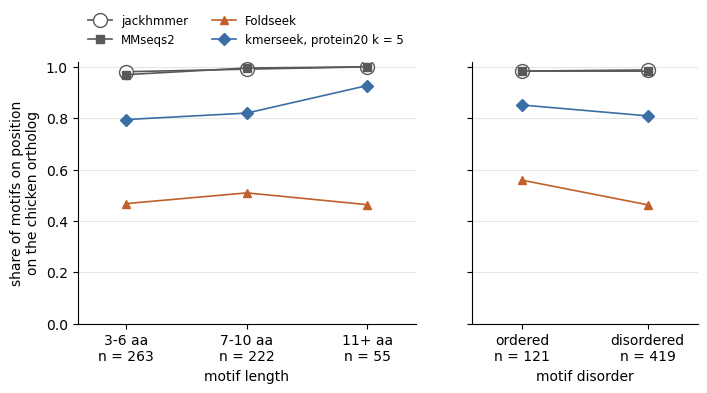

In [9]:
COV = pl.read_parquet(COVER.parent.parent / "elm_instance_covariates.parquet").select(
    "elm_instance", "frac_disordered_motif"
)
SHOW = {
    "hmmer3_jackhmmer": "jackhmmer",
    "mmseqs2_seqseq": "MMseqs2",
    "foldseek": "Foldseek",
    best_arm: "kmerseek, protein20 k = 5",
}
LB = (
    proj.filter(pl.col("arm").is_in(list(SHOW)) & pl.col("query_scoreable"))
    .join(COV, on="elm_instance", how="left")
    .with_columns(
        tool=pl.col("arm").replace_strict(SHOW),
        hit=pl.col("ortholog_rank_on_position").is_not_null(),
        length=pl.when(pl.col("motif_length") <= 6)
        .then(pl.lit("3-6 aa"))
        .when(pl.col("motif_length") <= 10)
        .then(pl.lit("7-10 aa"))
        .otherwise(pl.lit("11+ aa")),
        disorder=pl.when(pl.col("frac_disordered_motif") >= 0.5)
        .then(pl.lit("disordered"))
        .otherwise(pl.lit("ordered")),
    )
)
by = {}
for g, order in [("length", ["3-6 aa", "7-10 aa", "11+ aa"]), ("disorder", ["ordered", "disordered"])]:
    t = LB.group_by(g, "tool").agg(share=pl.col("hit").mean(), n=pl.len())
    by[g] = (t, order)
    print(f"Share on position by {g}:")
    print(t.pivot(on="tool", index=g, values="share").sort(g))
    print(t.filter(pl.col("tool") == "MMseqs2").select(g, "n").sort(g))
LB.group_by("length", "disorder", "tool").agg(share=pl.col("hit").mean(), n=pl.len()).sort(
    "length", "disorder", "tool"
).write_csv(TAB / "253_by_length_disorder.csv")

STYLE = {
    "jackhmmer": dict(color="0.35", marker="o", mfc="white", ms=10),
    "MMseqs2": dict(color="0.35", marker="s"),
    "Foldseek": dict(color="#C0612B", marker="^"),
    "kmerseek, protein20 k = 5": dict(color="#3B6EA5", marker="D"),
}
fig, axes = plt.subplots(1, 2, figsize=(8, 3.4), sharey=True, gridspec_kw={"width_ratios": [3, 2]})
for ax, (g, (t, order)) in zip(axes, by.items()):
    for tool, st in STYLE.items():
        d = t.filter(pl.col("tool") == tool)
        vals = [d.filter(pl.col(g) == o)["share"][0] for o in order]
        ax.plot(range(len(order)), vals, lw=1.2, label=tool, **{"ms": 6, **st})
    n = t.filter(pl.col("tool") == "MMseqs2")
    ax.set_xticks(
        range(len(order)),
        [f"{o}\nn = {n.filter(pl.col(g) == o)['n'][0]}" for o in order],
    )
    ax.set_xlim(-0.4, len(order) - 0.6)
    ax.grid(axis="y", color="0.9")
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
axes[0].set_ylim(0, 1.02)
axes[0].set_ylabel("share of motifs on position\non the chicken ortholog")
axes[0].set_xlabel("motif length")
axes[1].set_xlabel("motif disorder")
axes[0].legend(loc="lower left", bbox_to_anchor=(0, 1.02), ncol=2, frameon=False, fontsize=8.5)
fig.savefig(FIG / "253_by_length_disorder.png", dpi=200, bbox_inches="tight")


kmerseek does worse on short and on disordered motifs, as every sequence tool does, and the gap to
MMseqs2 is widest on the shortest motifs (79.5% against 97.0% at 3-6 aa; 92.7% against 100% at
11+ aa). On chicken, kmerseek is not better than the sequence tools on short or disordered motifs.
Chicken is close to human, so the sequence tools find nearly every ortholog here. The seven farther
species (PR #72) are where this can change.


## 9. Does the kmerseek score just follow call length?

For each kmerseek arm, this is the Spearman correlation between `region_mean_idf`, the
score that ranks its calls, and the call's length in residues. It uses a fixed sample of
about one call in 1_000. A score that tracks length ranks long calls first whatever they
match, which makes covering a motif easy for the wrong reason.

shape: (1, 4)
┌────────┬──────────┬───────────┬─────────┐
│ n_arms ┆ median   ┆ min       ┆ max     │
│ ---    ┆ ---      ┆ ---       ┆ ---     │
│ u32    ┆ f64      ┆ f64       ┆ f64     │
╞════════╪══════════╪═══════════╪═════════╡
│ 266    ┆ 0.795851 ┆ -0.179479 ┆ 0.92281 │
└────────┴──────────┴───────────┴─────────┘


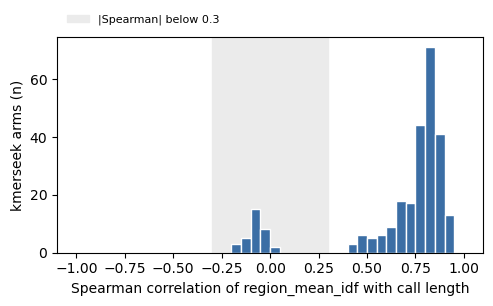

In [10]:
lc = S.filter(
    (pl.col("tool") == "kmerseek") & pl.col("spearman_vs_length").is_not_null()
)
print(
    lc.select(
        n_arms=pl.len(),
        median=pl.col("spearman_vs_length").median(),
        min=pl.col("spearman_vs_length").min(),
        max=pl.col("spearman_vs_length").max(),
    )
)
lc.select("arm", "spearman_vs_length").sort(
    "spearman_vs_length", descending=True
).write_csv(TAB / "253_length_check.csv")
fig, ax = plt.subplots(figsize=(5.5, 2.8))
ax.hist(
    lc["spearman_vs_length"],
    bins=np.linspace(-1, 1, 41),
    color="#3B6EA5",
    edgecolor="white",
)
ax.axvspan(-0.3, 0.3, color="0.92", zorder=0, label="|Spearman| below 0.3")
ax.set_xlabel("Spearman correlation of region_mean_idf with call length")
ax.set_ylabel("kmerseek arms (n)")
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01), frameon=False, fontsize=8)
fig.savefig(FIG / "253_length_check.png", dpi=200, bbox_inches="tight")

`region_mean_idf` follows call length: the median Spearman correlation over the 266 kmerseek arms is 0.80 (lowest -0.18, highest 0.92). Longer calls rank first whatever they match, which fits the low rank of the ortholog in section 5.

## What this says

Against chicken, kmerseek puts a human ELM motif on its ortholog's position less often than every sequence tool: 81.9% for its best arm, against 96.1% to 98.7%. It also puts the ortholog low in its list, and it places no motif that the comparison tools miss.

Chicken is close enough to human that the sequence tools find almost every ortholog, which leaves kmerseek nothing to add. The farther species are searched next (#72), with one arm per alphabet chosen here. Their results, not these, are the fair measure of those arms.

The ranking score follows call length (section 7). That affects every result that uses the list order, including the cut to 1_000 targets.